# Fraud Scoring Engine — ML component of the Fraud Investigation Copilot

**Role in the bigger system:** this notebook produces the *first-tier* fraud
score. Every transaction gets scored by this model. Low-risk transactions
auto-pass; anything at/above the risk threshold is handed to the LangGraph
agent for investigation (history retrieval, RAG over fraud patterns,
multi-tool reasoning), which always ends in a human-approval gate.

This is a **reworked version** of the original EDA/modelling notebook,
adapted so the model can be:
1. Trained on historical data (this notebook).
2. Saved as a reusable artifact (model + encoders + feature schema).
3. Called on a *single new transaction* at inference time via a
   `score_transaction()` function — this is the exact function that will
   become the agent's scoring tool later.

Two things were deliberately changed from the original notebook and are
called out inline: (a) **target leakage removed** from feature engineering,
and (b) categorical encoding is now inference-safe (handles unseen
categories instead of crashing).


In [6]:
%load_ext cuml.accel

In [1]:
# --- Core libraries ---
import numpy as np              # numeric arrays, vectorised feature math
import pandas as pd              # tabular data handling
import joblib                    # serialize the trained model + preprocessing artifacts to disk
import json                      # save small metadata (threshold, feature order) in a readable format

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder      # swapped in for LabelEncoder — see note below
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, precision_recall_curve,
    roc_curve, roc_auc_score, average_precision_score
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# Why OrdinalEncoder instead of LabelEncoder (as the original notebook used):
# LabelEncoder is fit per-column and throws an error the moment it sees a
# category it wasn't trained on. In production, a new sender_account,
# location, or device_hash WILL show up on day one. OrdinalEncoder with
# handle_unknown='use_encoded_value' maps unseen categories to a safe
# placeholder (-1) instead of crashing the scoring pipeline.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aryan208/financial-transactions-dataset-for-fraud-detection")

print("Path to dataset files:", path)

100%|██████████| 277M/277M [00:09<00:00, 31.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aryan208/financial-transactions-dataset-for-fraud-detection/versions/1


## 1. Load data
Point `DATA_PATH` at your local copy of the dataset (`financial_fraud_detection_dataset.csv`). The original notebook assumed a Kaggle-only path (`/kaggle/input/...`); that won't exist outside Kaggle, so it's replaced with a plain relative path you control.

In [3]:
DATA_PATH = "/root/.cache/kagglehub/datasets/aryan208/financial-transactions-dataset-for-fraud-detection/versions/1/financial_fraud_detection_dataset.csv"  # <-- update if your file lives elsewhere
df = pd.read_csv(DATA_PATH)
df.head()


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


## 2. Quick sanity checks
Same checks as the original EDA — shape, missing values, class balance. Kept minimal here since the goal of this notebook is a shippable scoring artifact, not a full EDA report (you already did that exploration in the original notebook; no need to duplicate every plot).

In [4]:
print("Shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())

fraud_rate = df["is_fraud"].mean() * 100
print(f"\nFraud rate: {fraud_rate:.3f}%  "
      f"({df['is_fraud'].sum()} fraud / {len(df)} total)")
# A ~<1-2% fraud rate is typical for real fraud data and is *why* we can't
# just train on raw accuracy — a model that predicts "never fraud" would
# already score >98% accuracy while being useless. This is why the original
# notebook (correctly) evaluates with precision/recall/AUPRC instead.


Shape: (5000000, 18)

Missing values per column:
 transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64

Fraud rate: 3.591%  (179553 fraud / 5000000 total)


## 3. Datetime feature extraction
Unchanged from the original: pull hour/day/day-of-week/month out of the raw timestamp so the model can learn time-based patterns (e.g. late-night transactions).

In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["day_of_week"] = df["timestamp"].dt.weekday
df["month"] = df["timestamp"].dt.month


## 4. Label to numeric
XGBoost (and sklearn generally) expects a numeric target, not True/False booleans.

In [7]:
df["is_fraud"] = df["is_fraud"].astype(int)


## 5. Handle missing values
Mean-imputation for numeric columns, same approach as the original notebook. Note: the imputer is **fit here and saved** — at inference time we reuse the *same* fitted imputer rather than recomputing means on a single incoming transaction (a single row has no distribution to impute from).

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove("is_fraud")  # never impute the label itself

imputer = SimpleImputer(strategy="mean")
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])


## 6. Drop `fraud_type`
`fraud_type` only exists *because* a transaction was fraud (it's a sub-category of the label itself), so keeping it would let the model "cheat" by learning is_fraud from a column that's really just a restatement of the label. Same call as the original notebook — this one was already correct.

In [9]:
df = df.drop(columns=["fraud_type"])


## 7. Encode categorical columns (inference-safe version)
**Changed from the original.** Instead of a fresh `LabelEncoder` per column (which errors on unseen categories), we use one `OrdinalEncoder` fit across all categorical columns together, with unknown categories mapped to `-1` instead of raising. This encoder object is saved and reused unchanged at inference time.

In [10]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns:", categorical_cols)

ordinal_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)
df[categorical_cols] = ordinal_encoder.fit_transform(df[categorical_cols].astype(str))
df.head()


Categorical columns: ['transaction_id', 'sender_account', 'receiver_account', 'transaction_type', 'merchant_category', 'location', 'device_used', 'payment_channel', 'ip_address', 'device_hash']


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,hour,day,day_of_week,month
0,0.0,2023-08-22 09:22:43.516168,774605.0,287290.0,343.78,3.0,7.0,6.0,1.0,0,...,-0.21,3.0,0.22,2.0,684409.0,3212380.0,9.0,22.0,1.0,8.0
1,11.0,2023-08-04 01:58:02.606711,792638.0,841820.0,419.65,3.0,2.0,7.0,0.0,0,...,-0.14,7.0,0.96,0.0,1616508.0,691787.0,1.0,4.0,4.0,8.0
2,22.0,2023-05-12 11:39:33.742963,630602.0,276316.0,2773.86,0.0,3.0,2.0,2.0,0,...,-1.78,20.0,0.89,2.0,1893332.0,1629699.0,11.0,12.0,4.0,5.0
3,33.0,2023-10-10 06:04:43.195112,893387.0,243162.0,1666.22,0.0,2.0,5.0,2.0,0,...,-0.60,6.0,0.37,3.0,198681.0,3819233.0,6.0,10.0,1.0,10.0
4,44.0,2023-09-24 08:09:02.700162,482844.0,396342.0,24.43,2.0,7.0,7.0,1.0,0,...,0.79,13.0,0.27,0.0,220250.0,2829128.0,8.0,24.0,6.0,9.0


## 8. Feature engineering — with target leakage removed
**Important fix.** The original notebook computed `sender_fraud_transaction` / `receiver_fraud_transaction` / `*_fraud_percentage` by aggregating `is_fraud` (the label) across each account. That's target leakage: the model effectively gets told "this account has X% fraud history" using future knowledge it wouldn't have at real prediction time, which inflates offline metrics and collapses in production. Those columns are **removed**. Everything else (amount ratios, velocity, network degree, time-of-day risk flags) is safe because it doesn't touch the label.

In [11]:
## Amount features
df["amount_per_velocity"] = df["amount"] / (df["velocity_score"] + 1)
df["amount_log"] = np.log1p(df["amount"])
df["amount_to_avg_ratio"] = df["amount"] / df.groupby("sender_account")["amount"].transform("mean")

## Frequency features
df["transaction_per_day"] = df.groupby(["sender_account", "day"])["amount"].transform("count")
df["transaction_gap"] = (
    df.groupby("sender_account")["timestamp"].diff().dt.total_seconds().fillna(0)
)

## Risk features
df["is_night_transaction"] = df["hour"].between(18, 24).astype(int)
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)  # fixed: weekday() range is 0-6, not 6/8
df["is_self_transfer"] = (df["sender_account"] == df["receiver_account"]).astype(int)

## Network features
df["sender_degree"] = df.groupby("sender_account")["receiver_account"].transform("nunique")
df["receiver_degree"] = df.groupby("receiver_account")["sender_account"].transform("nunique")
df["sender_total_transaction"] = df.groupby("sender_account")["amount"].transform("count")
df["receiver_total_transaction"] = df.groupby("receiver_account")["amount"].transform("count")

## Aggregation features
df["sender_avg_amount"] = df.groupby("sender_account")["amount"].transform("mean")
df["sender_std_amount"] = df.groupby("sender_account")["amount"].transform("std").fillna(0)

## Others
df["deviation_squared"] = df["spending_deviation_score"] ** 2

# NOTE: sender_fraud_transaction / receiver_fraud_transaction /
# sender_fraud_percentage / receiver_fraud_percentage were REMOVED here
# (target leakage — see markdown above).

df.head()


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,is_night_transaction,is_weekend,is_self_transfer,sender_degree,receiver_degree,sender_total_transaction,receiver_total_transaction,sender_avg_amount,sender_std_amount,deviation_squared
0,0.0,2023-08-22 09:22:43.516168,774605.0,287290.0,343.78,3.0,7.0,6.0,1.0,0,...,0,0,0,5,6,5,6,139.254000,134.787138,0.0441
1,11.0,2023-08-04 01:58:02.606711,792638.0,841820.0,419.65,3.0,2.0,7.0,0.0,0,...,0,0,0,6,5,6,5,168.301667,164.970814,0.0196
2,22.0,2023-05-12 11:39:33.742963,630602.0,276316.0,2773.86,0.0,3.0,2.0,2.0,0,...,0,0,0,7,4,7,4,597.892857,990.233513,3.1684
3,33.0,2023-10-10 06:04:43.195112,893387.0,243162.0,1666.22,0.0,2.0,5.0,2.0,0,...,0,0,0,4,5,4,5,694.362500,807.082916,0.3600
4,44.0,2023-09-24 08:09:02.700162,482844.0,396342.0,24.43,2.0,7.0,7.0,1.0,0,...,0,1,0,4,6,4,6,368.550000,652.920482,0.6241


## 9. Drop timestamp + finalize feature set
`timestamp` was only needed to derive hour/day/month/gap features; the raw datetime itself isn't a usable numeric feature, so it's dropped here — same as the original notebook, just kept at this stage instead of scattered later.

In [12]:
df = df.drop(columns=["timestamp"])

# Save the exact feature order now — this becomes part of the artifact
# bundle so score_transaction() can guarantee the same column order the
# model was trained on (XGBoost is order-sensitive by column position).
FEATURE_COLUMNS = [c for c in df.columns if c != "is_fraud"]
print(f"Final feature count: {len(FEATURE_COLUMNS)}")


Final feature count: 34


## 10. Balance classes for training only
Downsampling the majority class (same 2:1 ratio as the original notebook) so the model isn't overwhelmed by legitimate transactions during training. Important: this balanced set is **only used to fit the model** — at inference/serving time we still score the real, naturally imbalanced stream of transactions as they come in.

In [13]:
df_majority = df[df["is_fraud"] == 0]
df_minority = df[df["is_fraud"] == 1]

df_majority_downsampled = df_majority.sample(n=2 * len(df_minority), random_state=36)
df_balanced = pd.concat([df_majority_downsampled, df_minority])
print("Balanced shape:", df_balanced.shape)


Balanced shape: (538659, 35)


## 11. Train / validation / test split

In [14]:
y = df_balanced["is_fraud"]
X = df_balanced[FEATURE_COLUMNS]  # explicit column order, not just "drop is_fraud"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=36, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=1/8, random_state=36, stratify=y_train
)

print(len(X_train), len(X_val), len(X_test))


377061 53866 107732


## 12. Train the model — XGBoost only
**Changed from the original.** The original notebook trained and compared four models (XGBoost, MLPClassifier, RandomForest, IsolationForest). For this project we standardize on **XGBoost** as the single production model, because:
- it exposes `feature_importances_`, which the agent/report layer can surface to a human investigator ("flagged mainly due to velocity_score and geo_anomaly_score") — MLP and IsolationForest don't give this for free
- `scale_pos_weight` handles class imbalance natively, so we don't need a separate scaler/pipeline for it
- fastest to serve at low latency for a per-transaction scoring call

If you want to keep the model-comparison story for your resume/README, keep those experiments in a separate exploratory notebook and just cite the results — don't re-train 4 models every time this pipeline runs.

In [15]:
scale_pos_weight = y_train[y_train == 1].count() / y_train[y_train == 0].count()

xgb_model = XGBClassifier(
    n_estimators=300,
    objective="binary:logistic",
    tree_method="hist",
    max_depth=12,
    learning_rate=0.05,
    reg_lambda=3.6,
    reg_alpha=3.6,
    scale_pos_weight=scale_pos_weight,
    eval_metric=["aucpr"],
    subsample=0.8,
    n_jobs=-1,
    device="cuda",   # uncomment only if you're training on a GPU box (e.g. Kaggle T4/Modal L40S)
)

print("Training...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)
print("Training complete.")


Training...
[0]	validation_0-aucpr:0.44121	validation_1-aucpr:0.38129
[50]	validation_0-aucpr:0.80398	validation_1-aucpr:0.37900
[100]	validation_0-aucpr:0.89298	validation_1-aucpr:0.37754
[150]	validation_0-aucpr:0.93535	validation_1-aucpr:0.37779
[200]	validation_0-aucpr:0.96038	validation_1-aucpr:0.37793
[250]	validation_0-aucpr:0.97447	validation_1-aucpr:0.37857
[299]	validation_0-aucpr:0.98293	validation_1-aucpr:0.37985
Training complete.


## 13. Evaluate
Precision/recall curve, classification report, ROC-AUC, and feature importance — same evaluation approach as the original notebook, consolidated into one place.

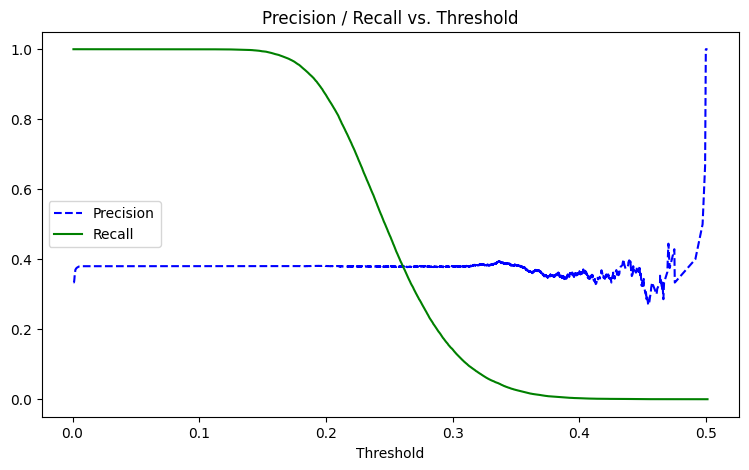

              precision    recall  f1-score   support

           0       0.67      1.00      0.80     71821
           1       1.00      0.00      0.00     35911

    accuracy                           0.67    107732
   macro avg       0.83      0.50      0.40    107732
weighted avg       0.78      0.67      0.53    107732

Average Precision (AUPRC): 0.3794
AUC-ROC: 0.5914


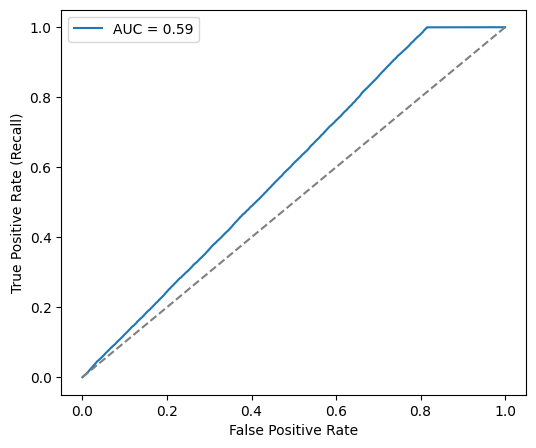

In [16]:
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.legend(loc="center left")
plt.title("Precision / Recall vs. Threshold")
plt.show()

print(classification_report(y_test, (y_pred_proba > 0.5).astype(int)))
print(f"Average Precision (AUPRC): {average_precision_score(y_test, y_pred_proba):.4f}")

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc_score:.4f}")
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.show()


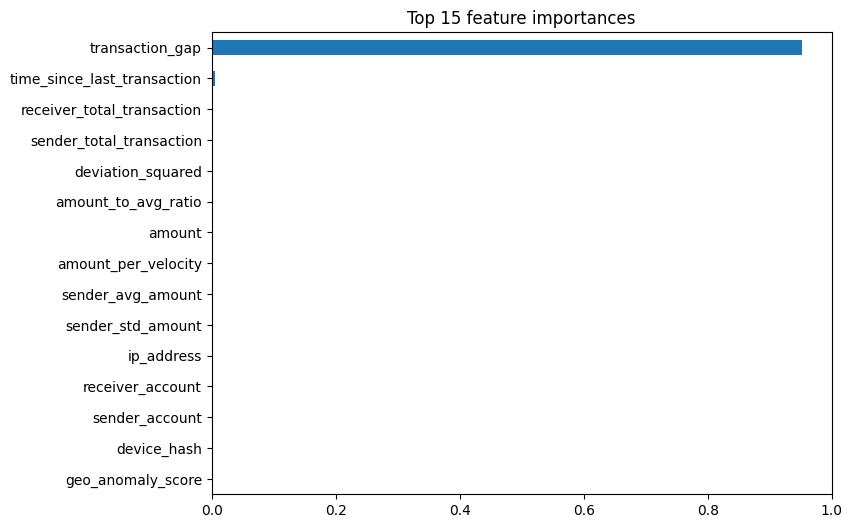

In [17]:
# Feature importance — this is what the agent's investigation report can
# cite when explaining *why* a transaction was flagged, instead of the LLM
# guessing at a justification.
importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLUMNS)
importances.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 feature importances")
plt.gca().invert_yaxis()
plt.show()


## 14. Pick the operating threshold
This threshold is the single most important design decision for the whole copilot, because it decides the split between "auto-pass" and "send to agent for investigation." We deliberately bias towards **recall over precision** here: missing real fraud is costlier than sending an extra legitimate transaction to the agent for a second look, since the agent + human step exists precisely to catch and correct the model's false positives before any real action is taken. Pick the lowest threshold that still keeps recall high without flooding the agent queue — inspect the precision/recall plot above and adjust `FLAG_THRESHOLD` to fit your own data.

In [30]:
FLAG_THRESHOLD = 0.3384  # tune against the precision/recall plot above

flagged = (y_pred_proba >= FLAG_THRESHOLD).astype(int)
print(classification_report(y_test, flagged))
print(f"Transactions flagged for investigation: {flagged.mean()*100:.2f}% of test set")


              precision    recall  f1-score   support

           0       0.67      0.97      0.79     71821
           1       0.39      0.04      0.08     35911

    accuracy                           0.66    107732
   macro avg       0.53      0.50      0.43    107732
weighted avg       0.58      0.66      0.55    107732

Transactions flagged for investigation: 3.56% of test set


## 15. Save the full artifact bundle
Everything needed to score a brand-new transaction later — model, encoder, imputer, feature order, and threshold — is saved together. This is what `score_transaction()` (and later, the LangGraph tool wrapper) will load.

In [31]:
import os
os.makedirs("artifacts", exist_ok=True)

joblib.dump(xgb_model, "artifacts/fraud_xgb_model.joblib")
joblib.dump(ordinal_encoder, "artifacts/ordinal_encoder.joblib")
joblib.dump(imputer, "artifacts/imputer.joblib")

metadata = {
    "feature_columns": FEATURE_COLUMNS,
    "categorical_columns": categorical_cols,
    "numeric_columns_for_imputation": numeric_cols,
    "flag_threshold": FLAG_THRESHOLD,
}
with open("artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model + preprocessing artifacts to ./artifacts/")


Saved model + preprocessing artifacts to ./artifacts/


## 16. Inference function — `score_transaction()`
This is the piece that turns a trained notebook into a usable system component. It takes **one new transaction** plus that sender's recent transaction history (from the SQLite history store — see project Task 2) and returns a fraud probability + flag decision.

Why it needs history: several engineered features (`amount_to_avg_ratio`, `transaction_per_day`, `sender_avg_amount`, `sender_degree`, ...) are only meaningful *relative to* a sender's past behaviour. A single transaction in isolation can't compute "average amount for this sender" — so this function recomputes those features using history + the new transaction combined, then scores only the new row. This exact function is what gets wrapped as the LangGraph tool in the agent stage.

In [ ]:
def score_transaction(new_transaction: dict, sender_history: pd.DataFrame) -> dict:
    """
    Score a single incoming transaction.

    Args:
        new_transaction: dict of raw transaction fields, same schema as the
            original CSV columns (sender_account, receiver_account, amount,
            timestamp, merchant_category, transaction_type,
            spending_deviation_score, velocity_score, geo_anomaly_score,
            ip_address, location, payment_channel, device_hash, ...).
        sender_history: DataFrame of that sender's past transactions
            (same raw schema), pulled from the history store. Can be empty
            for a brand-new sender — engineered ratios will just fall back
            to the transaction's own values.

    Returns:
        dict with fraud_probability, is_flagged, and top contributing
        features (for the agent/human to see *why*).
    """
    # 1. Combine history + new transaction so groupby-based features are
    #    computed the same way they were at training time.
    combined = pd.concat(
        [sender_history, pd.DataFrame([new_transaction])],
        ignore_index=True
    )
    combined["timestamp"] = pd.to_datetime(combined["timestamp"], errors="coerce")
    combined["hour"] = combined["timestamp"].dt.hour
    combined["day"] = combined["timestamp"].dt.day
    combined["day_of_week"] = combined["timestamp"].dt.weekday
    combined["month"] = combined["timestamp"].dt.month

    # 2. Impute numeric columns using the SAVED imputer (fit at training
    #    time) — never re-fit on a single row / small history slice.
    num_cols = [c for c in metadata["numeric_columns_for_imputation"] if c in combined.columns]
    combined[num_cols] = imputer.transform(combined[num_cols])

    # 3. Encode categoricals with the SAVED encoder — unseen categories
    #    (new device_hash, new location, etc.) safely map to -1 instead of
    #    crashing the pipeline.
    cat_cols = [c for c in metadata["categorical_columns"] if c in combined.columns]
    combined[cat_cols] = ordinal_encoder.transform(combined[cat_cols].astype(str))

    # 4. Re-derive the same engineered features as training (kept in sync
    #    with cell 8 above — if you change feature engineering there,
    #    mirror the change here).
    combined["amount_per_velocity"] = combined["amount"] / (combined["velocity_score"] + 1)
    combined["amount_log"] = np.log1p(combined["amount"])
    combined["amount_to_avg_ratio"] = combined["amount"] / combined.groupby("sender_account")["amount"].transform("mean")
    combined["transaction_per_day"] = combined.groupby(["sender_account", "day"])["amount"].transform("count")
    combined["transaction_gap"] = combined.groupby("sender_account")["timestamp"].diff().dt.total_seconds().fillna(0)
    combined["is_night_transaction"] = combined["hour"].between(18, 24).astype(int)
    combined["is_weekend"] = combined["day_of_week"].isin([5, 6]).astype(int)
    combined["is_self_transfer"] = (combined["sender_account"] == combined["receiver_account"]).astype(int)
    combined["sender_degree"] = combined.groupby("sender_account")["receiver_account"].transform("nunique")
    combined["receiver_degree"] = combined.groupby("receiver_account")["sender_account"].transform("nunique")
    combined["sender_total_transaction"] = combined.groupby("sender_account")["amount"].transform("count")
    combined["receiver_total_transaction"] = combined.groupby("receiver_account")["amount"].transform("count")
    combined["sender_avg_amount"] = combined.groupby("sender_account")["amount"].transform("mean")
    combined["sender_std_amount"] = combined.groupby("sender_account")["amount"].transform("std").fillna(0)
    combined["deviation_squared"] = combined["spending_deviation_score"] ** 2

    # 5. Take only the new transaction's row (the last one) and select
    #    columns in the EXACT saved training order.
    row = combined.iloc[[-1]][metadata["feature_columns"]]

    # 6. Predict.
    fraud_probability = float(xgb_model.predict_proba(row)[0, 1])
    is_flagged = fraud_probability >= metadata["flag_threshold"]

    # 7. Surface the features that most drove this specific score, so the
    #    agent's report and the human reviewer see something more useful
    #    than a bare number.
    contribution = (row.iloc[0] * pd.Series(xgb_model.feature_importances_, index=FEATURE_COLUMNS))
    top_features = contribution.abs().sort_values(ascending=False).head(5).index.tolist()

    return {
        "fraud_probability": round(fraud_probability, 4),
        "is_flagged": bool(is_flagged),
        "threshold_used": metadata["flag_threshold"],
        "top_contributing_features": top_features,
    }


## 17. Quick smoke test
Sanity-check the function on a row pulled straight from the test set before wiring it into the agent — cheap way to catch schema mismatches early.

In [33]:
# Grab one real transaction + treat the rest of that sender's rows in the
# test set as its "history" for a quick end-to-end check.
sample_idx = X_test.index[0]
# Note: X_test only has encoded/engineered columns; for a realistic test
# pull the ORIGINAL raw row (pre-encoding) from df_balanced's source data
# once you wire this against your real history store / DB in Task 2.
print("Smoke test placeholder — replace with a real raw transaction dict")
print("once the SQLite history store (Task 2) is in place.")


Smoke test placeholder — replace with a real raw transaction dict
once the SQLite history store (Task 2) is in place.


## Next steps (tie back to the project plan)
- **Task 1 (wrap as LangGraph tool):** `score_transaction()` above is ready to be wrapped almost as-is — the tool just needs to pull `sender_history` from the SQLite store instead of a DataFrame you pass manually.
- **Task 2 (transaction history store):** build the SQLite schema now so `sender_history` has a real source instead of the placeholder in cell 17.
- Re-run the threshold tuning (cell 14) once you see real flagged volume — if the agent queue is overwhelmed, raise `FLAG_THRESHOLD`; if fraud is slipping through as auto-pass, lower it.
